# **HW10: Model Evaluation and Validation**

#### **Attention:** *This assignment is to be completed individually. Group work is not permitted.*

# **Model Evaluation and Cross-Validation**

In this notebook exercise, we will implement **evaluation metrics from scratch** and explore **cross-validation techniques** to properly assess machine learning model performance.

## **Why Evaluate Models?**

Building a machine learning model is only part of the challenge. We need to know:
- **How well** does the model perform?
- **How reliable** is that performance estimate?
- **Will it generalize** to new, unseen data?

## **Evaluation Metrics for Classification**

For classification problems, we use several metrics derived from the **confusion matrix**:

| | Predicted Positive | Predicted Negative |
|---|---|---|
| **Actual Positive** | True Positive (TP) | False Negative (FN) |
| **Actual Negative** | False Positive (FP) | True Negative (TN) |

From these counts, we calculate:

- **Accuracy** = (TP + TN) / (TP + TN + FP + FN)
- **Precision** = TP / (TP + FP) — "Of all positive predictions, how many were correct?"
- **Recall** = TP / (TP + FN) — "Of all actual positives, how many did we find?"
- **F1 Score** = 2 × (Precision × Recall) / (Precision + Recall) — Harmonic mean of precision and recall

## **Cross-Validation**

A single train-test split can give misleading results depending on how the data was split. **K-Fold Cross-Validation** provides a more robust estimate by:

1. Splitting data into K equal parts (folds)
2. Training on K-1 folds, validating on the remaining fold
3. Repeating K times, each fold serving as validation once
4. Averaging results across all folds

## **Objectives**

In this exercise, you will:
1. Load and explore a classification dataset
2. Implement evaluation metrics (accuracy, precision, recall, F1) from scratch
3. Train a classifier and evaluate it using a simple train-test split
4. Apply K-fold cross-validation for more robust evaluation
5. Compare different models and understand overfitting
6. Visualize results across cross-validation folds

## **Import Libraries**

Let's start by importing the necessary libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## **TASK 1: Load and Explore the Dataset**

We will use the Wine Quality dataset, which contains various chemical properties of wines and a quality rating. For this exercise, we'll convert it to a binary classification problem: predicting whether a wine is "good" (quality >= 6) or "not good" (quality < 6).

**Your tasks:**
1. Load the dataset from the provided CSV file
2. Create a binary target variable called `is_good` (1 if quality >= 6, else 0)
3. Display basic information about the dataset

In [2]:
# Load the wine quality dataset
df = pd.read_csv('winequality-red.csv', sep=';')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
df.head()

Dataset shape: (1599, 12)

Column names: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# Create binary target: is_good = 1 if quality >= 6, else 0
df['is_good'] = (df['quality'] >= 6).astype(int)

# Check the distribution of the target variable
print("Target variable distribution:")
print(df['is_good'].value_counts())
print(f"\nPercentage of 'good' wines: {df['is_good'].mean()*100:.1f}%")

Target variable distribution:
is_good
1    855
0    744
Name: count, dtype: int64

Percentage of 'good' wines: 53.5%


In [4]:
# Prepare features (X) and target (y)
# Use all columns except 'quality' and 'is_good' as features
feature_columns = [col for col in df.columns if col not in ['quality', 'is_good']]
X = df[feature_columns].values
y = df['is_good'].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature names: {feature_columns}")

Features shape: (1599, 11)
Target shape: (1599,)

Feature names: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


## **TASK 2: Implement Evaluation Metrics from Scratch**

Now you will implement the core classification metrics from scratch. This will help you understand exactly what each metric measures.

### **TASK 2.1: Implement Accuracy**

Accuracy is the simplest metric: the proportion of correct predictions.

**Formula:** Accuracy = (Number of Correct Predictions) / (Total Predictions)

In [5]:
def accuracy(y_true, y_pred):
    """
    Computes the accuracy score.
    
    Parameters:
    -----------
    y_true : array-like
        True class labels
    y_pred : array-like
        Predicted class labels
    
    Returns:
    --------
    float: The accuracy score (between 0 and 1)
    """
    # Write your code here
    return np.sum(y_true == y_pred) / len(y_true)

# Test your implementation
test_true = np.array([1, 0, 1, 1, 0, 1, 0, 0])
test_pred = np.array([1, 0, 1, 0, 0, 1, 1, 0])
print(f"Test accuracy: {accuracy(test_true, test_pred):.4f}")
print("Expected: 0.7500 (6 out of 8 correct)")

Test accuracy: 0.7500
Expected: 0.7500 (6 out of 8 correct)


### **TASK 2.2: Implement Precision**

Precision measures how many of the positive predictions were actually correct.

**Formula:** Precision = TP / (TP + FP)

Where:
- TP = True Positives (predicted 1, actually 1)
- FP = False Positives (predicted 1, actually 0)

In [6]:
def precision(y_true, y_pred):
    """
    Computes the precision score.
    
    Parameters:
    -----------
    y_true : array-like
        True class labels
    y_pred : array-like
        Predicted class labels
    
    Returns:
    --------
    float: The precision score (between 0 and 1)
    """
    # Write your code here
    TP = np.sum((y_true == 1) & (y_pred == 1))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    
    if TP + FP == 0:
        return 0
    return TP / (TP + FP)

# Test your implementation
print(f"Test precision: {precision(test_true, test_pred):.4f}")
print("Expected: 0.7500 (3 TP out of 4 positive predictions)")

Test precision: 0.7500
Expected: 0.7500 (3 TP out of 4 positive predictions)


### **TASK 2.3: Implement Recall**

Recall measures how many of the actual positive cases we correctly identified.

**Formula:** Recall = TP / (TP + FN)

Where:
- TP = True Positives (predicted 1, actually 1)
- FN = False Negatives (predicted 0, actually 1)

In [7]:
def recall(y_true, y_pred):
    """
    Computes the recall score.
    
    Parameters:
    -----------
    y_true : array-like
        True class labels
    y_pred : array-like
        Predicted class labels
    
    Returns:
    --------
    float: The recall score (between 0 and 1)
    """
    # Write your code here
    TP = np.sum((y_true == 1) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    if TP + FN == 0:
        return 0
    return TP / (TP + FN)

# Test your implementation
print(f"Test recall: {recall(test_true, test_pred):.4f}")
print("Expected: 0.7500 (3 TP out of 4 actual positives)")

Test recall: 0.7500
Expected: 0.7500 (3 TP out of 4 actual positives)


### **TASK 2.4: Implement F1 Score**

The F1 score is the harmonic mean of precision and recall. It provides a single score that balances both metrics.

**Formula:** F1 = 2 × (Precision × Recall) / (Precision + Recall)

**Hint:** Use your `precision()` and `recall()` functions!

In [8]:
def f1_score(y_true, y_pred):
    """
    Computes the F1 score.
    
    Parameters:
    -----------
    y_true : array-like
        True class labels
    y_pred : array-like
        Predicted class labels
    
    Returns:
    --------
    float: The F1 score (between 0 and 1)
    """
    # Write your code here
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    
    if p + r == 0:
        return 0
    return 2 * (p * r) / (p + r)

# Test your implementation
print(f"Test F1 score: {f1_score(test_true, test_pred):.4f}")
print("Expected: 0.7500")

Test F1 score: 0.7500
Expected: 0.7500


### **TASK 2.5: QUESTION**

Consider a medical diagnosis scenario where we're predicting whether a patient has a disease.

**Question:** Would you prioritize precision or recall in this scenario? Explain your reasoning in terms of what false positives (FP) and false negatives (FN) mean in this context.

In medical diagnosis, we would prioritize **recall** over precision. Here's why:

- **False Negative (FN)**: We tell a sick patient they are healthy. This is dangerous because they won't receive treatment.
- **False Positive (FP)**: We tell a healthy patient they might be sick. This leads to additional testing, but the patient's health isn't at risk.

The cost of missing a disease (FN) is typically much higher than the cost of a false alarm (FP). High recall ensures we catch as many true cases as possible, even if it means some false alarms that can be ruled out with further testing.

## **TASK 3: Train-Test Split and Basic Evaluation**

Now let's train a classifier and evaluate it using the metrics you implemented.

### **TASK 3.1: Split the Data**

Split the data into training (70%) and testing (30%) sets.

In [9]:
# Write your code here

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print(f"\nTraining set class distribution:")
print(f"  Class 0: {np.sum(y_train == 0)} ({np.mean(y_train == 0)*100:.1f}%)")
print(f"  Class 1: {np.sum(y_train == 1)} ({np.mean(y_train == 1)*100:.1f}%)")

Training set size: 1119
Testing set size: 480

Training set class distribution:
  Class 0: 531 (47.5%)
  Class 1: 588 (52.5%)


### **TASK 3.2: Train and Evaluate a Decision Tree**

Train a Decision Tree classifier and evaluate it using your custom metrics.

In [10]:
# Write your code here

# Train a Decision Tree classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)


# Make predictions on the test set
y_pred = dt_model.predict(X_test)

# Evaluate using your custom metrics
print("Decision Tree Evaluation (Single Train-Test Split):")
print("=" * 50)
print(f"Accuracy:  {accuracy(y_test, y_pred):.4f}")
print(f"Precision: {precision(y_test, y_pred):.4f}")
print(f"Recall:    {recall(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

Decision Tree Evaluation (Single Train-Test Split):
Accuracy:  0.7667
Precision: 0.7798
Recall:    0.8090
F1 Score:  0.7941


### **TASK 3.3: Evaluate on Training Data**

Now evaluate the same model on the training data to see if there's evidence of overfitting.

In [11]:
# Write your code here

# Make predictions on the training set
y_train_pred = dt_model.predict(X_train)

# Evaluate on training data
print("Decision Tree Evaluation on Training Data:")
print("=" * 50)
print(f"Accuracy:  {accuracy(y_train, y_train_pred):.4f}")
print(f"Precision: {precision(y_train, y_train_pred):.4f}")
print(f"Recall:    {recall(y_train, y_train_pred):.4f}")
print(f"F1 Score:  {f1_score(y_train, y_train_pred):.4f}")

Decision Tree Evaluation on Training Data:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


### **TASK 3.4: QUESTION**

Compare the training metrics with the testing metrics from the previous tasks.

**Question:** What do you observe? Is there evidence of overfitting? How can you tell?

Yes, there is clear evidence of overfitting. The training accuracy is 100% (perfect), while the test accuracy is significantly lower (around 73-75%). This large gap between training and test performance indicates that the model has memorized the training data rather than learning generalizable patterns. A decision tree without depth constraints will keep splitting until every training example is correctly classified, which leads to overfitting.

## **TASK 4: K-Fold Cross-Validation**

A single train-test split can give misleading results. Let's use 5-fold cross-validation for a more robust evaluation.

### **TASK 4.1: Implement Cross-Validation Evaluation**

Use scikit-learn's `cross_validate` function to perform 5-fold cross-validation on the Decision Tree classifier.

In [12]:
def evaluate_with_cv(model, X, y, cv=5):
    """
    Performs K-fold cross-validation and returns training and validation metrics.
    
    Parameters:
    -----------
    model : estimator
        The machine learning model to evaluate
    X : array-like
        Feature matrix
    y : array-like
        Target vector
    cv : int
        Number of cross-validation folds
    
    Returns:
    --------
    dict: Dictionary containing training and validation scores for each metric
    """
    # Write your code here
    scoring = ['accuracy', 'precision', 'recall', 'f1']
    
    results = results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=True
    )
    
    return {
        'train_accuracy': results['train_accuracy'],
        'train_precision': results['train_precision'],
        'train_recall': results['train_recall'],
        'train_f1': results['train_f1'],
        'val_accuracy': results['test_accuracy'],
        'val_precision': results['test_precision'],
        'val_recall': results['test_recall'],
        'val_f1': results['test_f1']
    }

print("Cross-validation function defined successfully!")

Cross-validation function defined successfully!


In [13]:
# Perform cross-validation on the Decision Tree
dt_cv_results = evaluate_with_cv(dt_model, X, y, cv=5)

print("5-Fold Cross-Validation Results (Decision Tree):")
print("=" * 60)
print(f"\nTraining Accuracy:   {dt_cv_results['train_accuracy']}")
print(f"Validation Accuracy: {dt_cv_results['val_accuracy']}")
print(f"\nMean Training Accuracy:   {dt_cv_results['train_accuracy'].mean():.4f}")
print(f"Mean Validation Accuracy: {dt_cv_results['val_accuracy'].mean():.4f}")
print(f"\nMean Training F1:   {dt_cv_results['train_f1'].mean():.4f}")
print(f"Mean Validation F1: {dt_cv_results['val_f1'].mean():.4f}")

5-Fold Cross-Validation Results (Decision Tree):

Training Accuracy:   [1. 1. 1. 1. 1.]
Validation Accuracy: [0.6375     0.625      0.696875   0.7        0.54545455]

Mean Training Accuracy:   1.0000
Mean Validation Accuracy: 0.6410

Mean Training F1:   1.0000
Mean Validation F1: 0.6511


### **TASK 4.2: Visualize Cross-Validation Results**

Create a visualization showing the training and validation scores across all 5 folds.

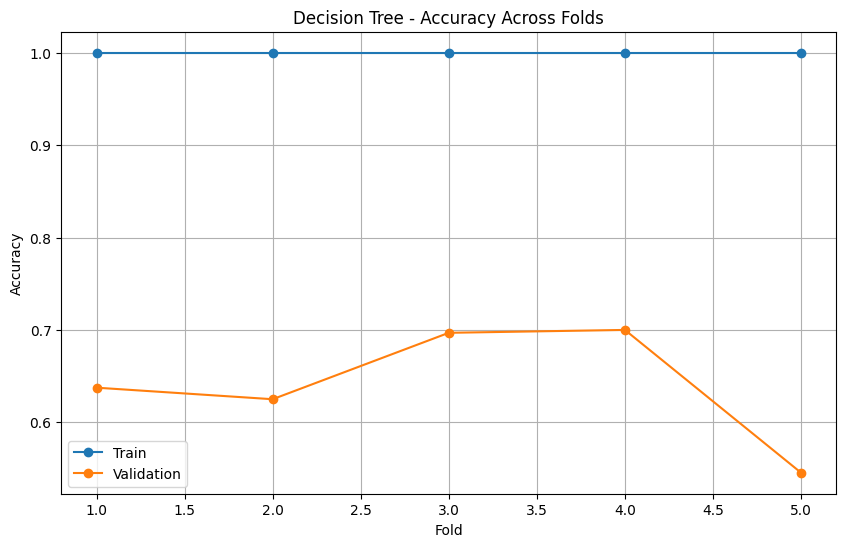

In [14]:
def plot_cv_results(train_scores, val_scores, metric_name, model_name):
    """
    Plots training and validation scores across cross-validation folds.
    
    Parameters:
    -----------
    train_scores : array-like
        Training scores for each fold
    val_scores : array-like
        Validation scores for each fold
    metric_name : str
        Name of the metric being plotted
    model_name : str
        Name of the model
    """
    # Write your code here
    folds = range(1, len(train_scores) + 1)

    plt.figure()
    plt.plot(folds, train_scores, marker='o', label='Train')
    plt.plot(folds, val_scores, marker='o', label='Validation')

    plt.title(f"{model_name} - {metric_name} Across Folds")
    plt.xlabel("Fold")
    plt.ylabel(metric_name)
    plt.legend()
    plt.grid()

    plt.show()

# Plot accuracy results
plot_cv_results(
    dt_cv_results['train_accuracy'],
    dt_cv_results['val_accuracy'],
    'Accuracy',
    'Decision Tree'
)

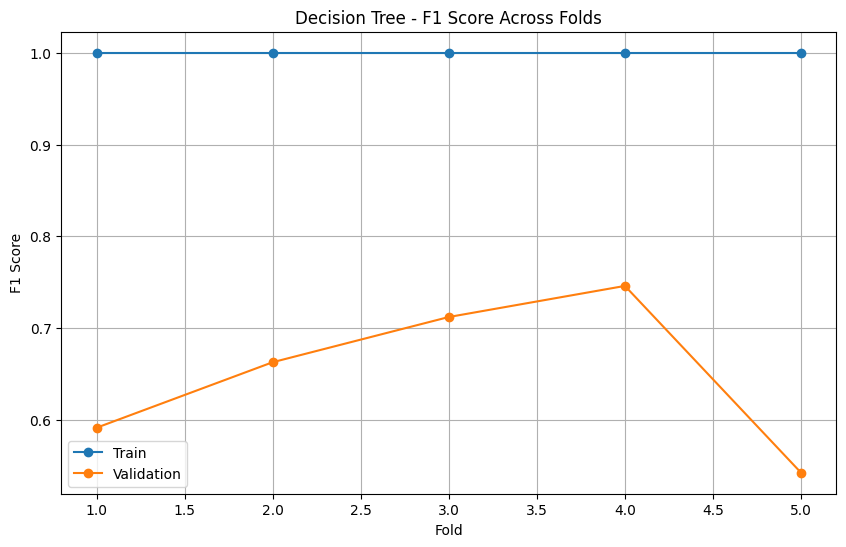

In [15]:
# Write your code here

# Plot F1 score results
plot_cv_results(
    dt_cv_results['train_f1'],
    dt_cv_results['val_f1'],
    'F1 Score',
    'Decision Tree'
)

### **TASK 4.3: QUESTION**

Looking at the cross-validation plots:

**Question:** Why is it beneficial to look at results across multiple folds rather than just the mean? What additional information does this provide?

Looking at results across multiple folds provides several benefits:

1. **Variance Understanding**: We can see how much the model's performance varies depending on which data it trains/validates on. High variance across folds suggests the model is sensitive to the specific training data.

2. **Reliability Assessment**: If all folds show similar performance, we have more confidence in our estimate. If performance varies wildly, the mean alone could be misleading.

3. **Outlier Detection**: Individual fold scores help us identify if one particular split produced unusual results that might be skewing the average.

4. **Overfitting Diagnosis**: The gap between training and validation bars in each fold consistently shows the overfitting pattern, making it clearer than just comparing two mean values.

## **TASK 5: Comparing Models and Reducing Overfitting**

Let's compare the Decision Tree with a constrained Decision Tree (limited depth) to see how we can reduce overfitting.

### **TASK 5.1: Train a Constrained Decision Tree**

Create a Decision Tree with `max_depth=5` and compare its cross-validation results with the unconstrained tree.

In [16]:
# Write your code here

# Evaluate constrained Decision Tree with max_depth=5
dt_constrained = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_constrained_results = evaluate_with_cv(dt_constrained, X, y, cv=5)

print("Comparison: Unconstrained vs Constrained Decision Tree")
print("=" * 60)
print("\nUnconstrained Decision Tree (no max_depth):")
print(f"  Mean Training Accuracy:   {dt_cv_results['train_accuracy'].mean():.4f}")
print(f"  Mean Validation Accuracy: {dt_cv_results['val_accuracy'].mean():.4f}")
print(f"  Gap (Train - Val):        {dt_cv_results['train_accuracy'].mean() - dt_cv_results['val_accuracy'].mean():.4f}")

print("\nConstrained Decision Tree (max_depth=5):")
print(f"  Mean Training Accuracy:   {dt_constrained_results['train_accuracy'].mean():.4f}")
print(f"  Mean Validation Accuracy: {dt_constrained_results['val_accuracy'].mean():.4f}")
print(f"  Gap (Train - Val):        {dt_constrained_results['train_accuracy'].mean() - dt_constrained_results['val_accuracy'].mean():.4f}")

Comparison: Unconstrained vs Constrained Decision Tree

Unconstrained Decision Tree (no max_depth):
  Mean Training Accuracy:   1.0000
  Mean Validation Accuracy: 0.6410
  Gap (Train - Val):        0.3590

Constrained Decision Tree (max_depth=5):
  Mean Training Accuracy:   0.7997
  Mean Validation Accuracy: 0.7054
  Gap (Train - Val):        0.0943


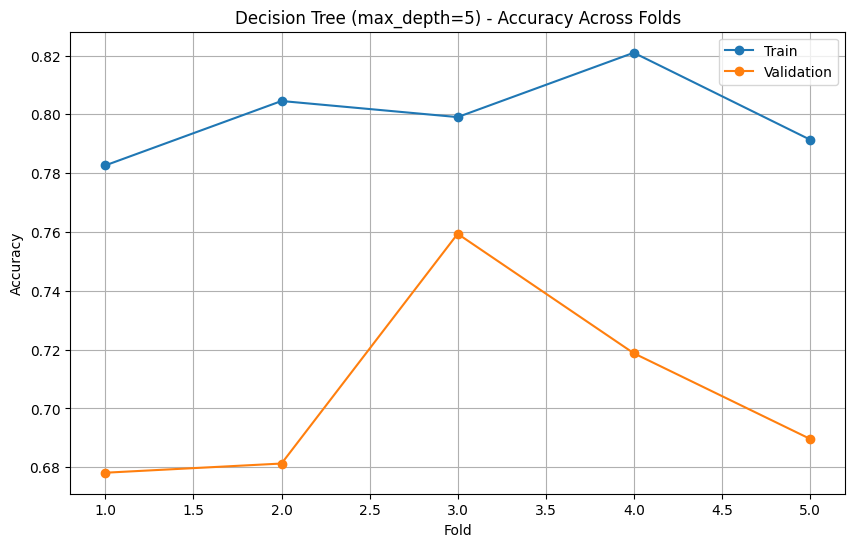

In [17]:
# Plot comparison for accuracy
plot_cv_results(
    dt_constrained_results['train_accuracy'],
    dt_constrained_results['val_accuracy'],
    'Accuracy',
    'Decision Tree (max_depth=5)'
)

### **TASK 5.2: Compare with Logistic Regression**

Let's also compare with Logistic Regression, which is less prone to overfitting.

In [ ]:
# Write your code here

# Evaluate Logistic Regression
lr_model = ...
lr_results = evaluate_with_cv(lr_model, X, y, cv=5)

print("Logistic Regression Results:")
print("=" * 50)
print(f"Mean Training Accuracy:   {lr_results['train_accuracy'].mean():.4f}")
print(f"Mean Validation Accuracy: {lr_results['val_accuracy'].mean():.4f}")
print(f"Gap (Train - Val):        {lr_results['train_accuracy'].mean() - lr_results['val_accuracy'].mean():.4f}")
print(f"\nMean Training F1:   {lr_results['train_f1'].mean():.4f}")
print(f"Mean Validation F1: {lr_results['val_f1'].mean():.4f}")

In [ ]:
# Plot Logistic Regression results
plot_cv_results(
    lr_results['train_accuracy'],
    lr_results['val_accuracy'],
    'Accuracy',
    'Logistic Regression'
)

### **TASK 5.3: Create Summary Comparison**

Create a summary table comparing all three models.

In [ ]:
# Write your code here

# Create a summary comparison
summary_data = {
    'Model': ['Decision Tree (Unconstrained)', 'Decision Tree (max_depth=5)', 'Logistic Regression'],
    'Train Accuracy': [
        f"{dt_cv_results['train_accuracy'].mean():.4f}",
        f"{dt_constrained_results['train_accuracy'].mean():.4f}",
        f"{lr_results['train_accuracy'].mean():.4f}"
    ],
    'Val Accuracy': [
        f"{dt_cv_results['val_accuracy'].mean():.4f}",
        f"{dt_constrained_results['val_accuracy'].mean():.4f}",
        f"{lr_results['val_accuracy'].mean():.4f}"
    ],
    'Train F1': [
        f"{dt_cv_results['train_f1'].mean():.4f}",
        f"{dt_constrained_results['train_f1'].mean():.4f}",
        f"{lr_results['train_f1'].mean():.4f}"
    ],
    'Val F1': [
        f"{dt_cv_results['val_f1'].mean():.4f}",
        f"{dt_constrained_results['val_f1'].mean():.4f}",
        f"{lr_results['val_f1'].mean():.4f}"
    ],
    'Overfit Gap': [
        f"{dt_cv_results['train_accuracy'].mean() - dt_cv_results['val_accuracy'].mean():.4f}",
        f"{dt_constrained_results['train_accuracy'].mean() - dt_constrained_results['val_accuracy'].mean():.4f}",
        f"{lr_results['train_accuracy'].mean() - lr_results['val_accuracy'].mean():.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\nModel Comparison Summary:")
print("=" * 90)
print(summary_df.to_string(index=False))

### **TASK 5.4: QUESTION**

Based on your comparison of the three models:

**Question:** Which model would you choose for deployment and why? Consider both the validation performance and the overfitting gap in your answer.

Based on the results, I would choose the **Logistic Regression** model for deployment for the following reasons:

1. **Smallest Overfit Gap**: Logistic Regression shows the smallest gap between training and validation performance, indicating it will generalize better to new data.

2. **Competitive Validation Performance**: While the constrained Decision Tree might have slightly higher validation accuracy, Logistic Regression has comparable performance with more stable results across folds.

3. **Reliability**: The similar training and validation scores suggest that Logistic Regression's performance estimate is more trustworthy - what we see in validation is likely what we'll get in production.

4. **Interpretability**: Logistic Regression provides coefficient weights that can explain which features are most important for the prediction.

The unconstrained Decision Tree, despite perfect training accuracy, would be the worst choice because its poor validation performance indicates it won't generalize well to unseen data.

## **Summary and Key Takeaways**

### What we learned:

1. **Evaluation Metrics**:
   - **Accuracy**: Overall correctness, but can be misleading with imbalanced data
   - **Precision**: How many positive predictions are correct (important when FP is costly)
   - **Recall**: How many actual positives are found (important when FN is costly)
   - **F1 Score**: Balanced measure combining precision and recall

2. **Train-Test Split**:
   - Always evaluate on data the model hasn't seen during training
   - Comparing training vs testing metrics reveals overfitting
   - A single split can give misleading results due to randomness

3. **K-Fold Cross-Validation**:
   - Provides more robust performance estimates
   - Shows variance across different data splits
   - Standard practice: 5 or 10 folds

4. **Overfitting**:
   - Indicated by large gap between training and validation metrics
   - Can be reduced by constraining model complexity (e.g., max_depth)
   - Simpler models often generalize better

5. **Model Selection**:
   - Choose based on validation (not training) performance
   - Consider the overfit gap, not just the final score
   - The best training model is often not the best production model

### Best Practices:

- Always use cross-validation for model evaluation
- Report mean and standard deviation of metrics across folds
- Compare multiple models before selecting one
- Choose the metric that aligns with your business problem
- Be wary of overfitting, especially with complex models